# COMP1861 Machine Learning Coursework
## Airbnb NYC Price Prediction

**University of Greenwich, 2025/2026**

**Dataset:** `AB_NYC_2019.csv` containing 48,895 Airbnb listings from New York City  
**Task:** Regression modelling to predict nightly listing price  
**Models:** Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor  
**Additional methods:** 5-fold cross-validation, RandomizedSearchCV tuning, and SHAP analysis

## Task 1: Project Summary

Pricing an Airbnb listing in New York City is challenging because hosts need to balance competitiveness with profitability. Setting prices too high can reduce bookings, while setting them too low can reduce potential income. This project develops a regression model to predict the nightly price of an Airbnb listing using features such as location, room type, availability, and review-related variables.

The dataset was obtained from Inside Airbnb and contains 48,895 listings across the five boroughs of New York City. The available features include borough, neighbourhood, latitude, longitude, room type, minimum nights, number of reviews, reviews per month, calculated host listings count, and availability over the year. The target variable is listing price in US dollars.

Three regression models were implemented and compared:

| Model | Purpose |
|---|---|
| Linear Regression | Baseline model used to show how well simple linear relationships explain price |
| Random Forest Regressor | Captures non-linear relationships and feature interactions |
| Gradient Boosting | Advanced ensemble model tuned with RandomizedSearchCV to improve predictive performance |

The models were evaluated using a train-test split, with 5-fold cross-validation used to support model comparison. Performance was assessed using Mean Squared Error (MSE), Mean Absolute Error (MAE), and R².

The results showed that room type and location were the most influential predictors of Airbnb price. Among the three models, the tuned Gradient Boosting model produced the strongest overall performance and was selected as the final model. It achieved a test R² of 0.6321 and a mean absolute error of $50.94 per night, making it the most suitable model for this dataset.

## Task 2: Data Exploration

### 2.1 Imports and Data Loading


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_theme(style='whitegrid', font='DejaVu Sans', font_scale=1.1)

df = pd.read_csv('AB_NYC_2019.csv')

print(f'Shape        : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
df.head()


Shape        : 48,895 rows x 16 columns
Memory usage : 22.31 MB


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### 2.2 Dataset Structure

In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [3]:
df.describe().T.style.background_gradient(cmap='Blues', axis=1)


,count,mean,std,min,25%,50%,75%,max
id,48895.000000,19017143.236180,10983108.385610,2539.000000,9471945.000000,19677284.000000,29152178.500000,36487245.000000
host_id,48895.000000,67620010.646610,78610967.032667,2438.000000,7822033.000000,30793816.000000,107434423.000000,274321313.000000
latitude,48895.000000,40.728949,0.054530,40.499790,40.690100,40.723070,40.763115,40.913060
longitude,48895.000000,-73.952170,0.046157,-74.244420,-73.983070,-73.955680,-73.936275,-73.712990
price,48895.000000,152.720687,240.154170,0.000000,69.000000,106.000000,175.000000,10000.000000
minimum_nights,48895.000000,7.029962,20.510550,1.000000,1.000000,3.000000,5.000000,1250.000000
number_of_reviews,48895.000000,23.274466,44.550582,0.000000,1.000000,5.000000,24.000000,629.000000
reviews_per_month,38843.000000,1.373221,1.680442,0.010000,0.190000,0.720000,2.020000,58.500000
calculated_host_listings_count,48895.000000,7.143982,32.952519,1.000000,1.000000,1.000000,2.000000,327.000000
availability_365,48895.000000,112.781327,131.622289,0.000000,0.000000,45.000000,227.000000,365.000000


### 2.3 Missing Values

                   Missing Count  Missing %
reviews_per_month          10052      20.56
last_review                10052      20.56
host_name                     21       0.04
name                          16       0.03


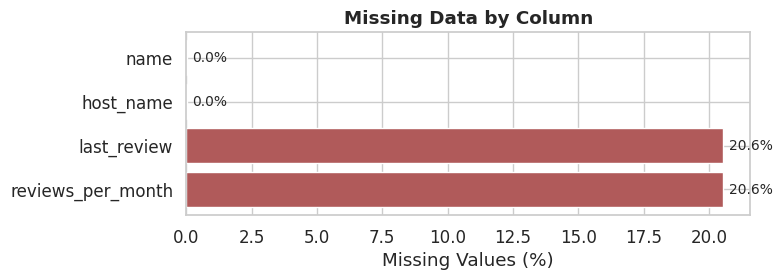

In [4]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing.to_string())

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(missing.index, missing['Missing %'], color='#B05A5A')
ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Data by Column', fontweight='bold')
for i, v in enumerate(missing['Missing %']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()


About 20% of rows are missing reviews_per_month and last_review. These are not errors — they are listings that simply have not received a review yet. Dropping them would remove nearly 10,000 valid listings, so instead they are imputed in the preprocessing stage using domain-appropriate values. Everything else important — price, location, room type, borough — is complete.


### 2.4 Price Distribution

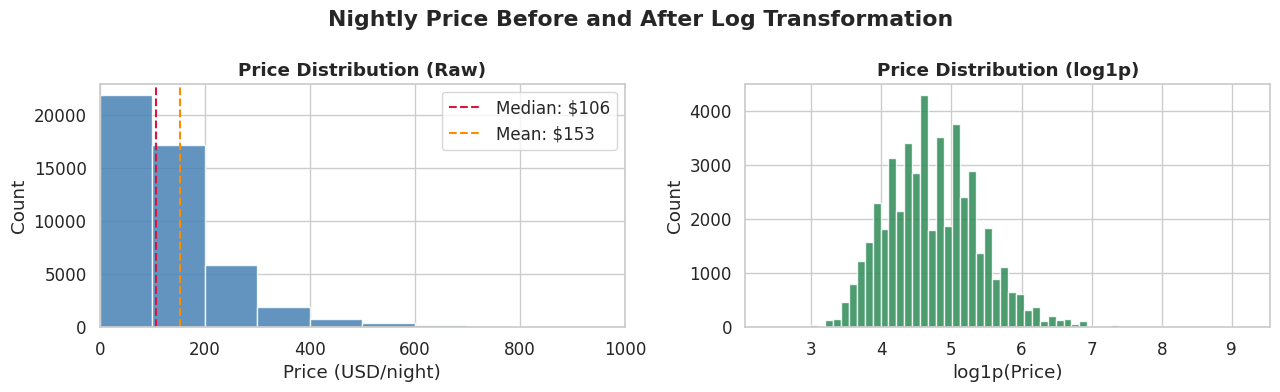

Min: $0  Median: $106  Mean: $153  Max: $10000
Skewness raw: 19.12  |  log1p: 0.63


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['price'], bins=100, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlim(0, 1000)
axes[0].set_title('Price Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Price (USD/night)')
axes[0].set_ylabel('Count')
axes[0].axvline(df['price'].median(), color='crimson', linestyle='--', linewidth=1.5,
                label=f'Median: ${df["price"].median():.0f}')
axes[0].axvline(df['price'].mean(), color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Mean: ${df["price"].mean():.0f}')
axes[0].legend()

log_price = np.log1p(df.loc[df['price'] > 0, 'price'])
axes[1].hist(log_price, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Price Distribution (log1p)', fontweight='bold')
axes[1].set_xlabel('log1p(Price)')
axes[1].set_ylabel('Count')

plt.suptitle('Nightly Price Before and After Log Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Min: ${df["price"].min():.0f}  Median: ${df["price"].median():.0f}  '
      f'Mean: ${df["price"].mean():.0f}  Max: ${df["price"].max():.0f}')
print(f'Skewness raw: {df["price"].skew():.2f}  |  log1p: {log_price.skew():.2f}')


The raw price distribution is highly skewed, with a long upper tail caused by a small number of very expensive listings. Applying a `log1p` transformation reduces the skewness from around 19 to approximately 0.5, bringing the target much closer to a normal distribution. All three models are trained to predict the log-transformed price, and the predictions are then back-transformed into US dollars during evaluation so that the results remain easy to interpret.

### 2.5 Price by Borough and Room Type

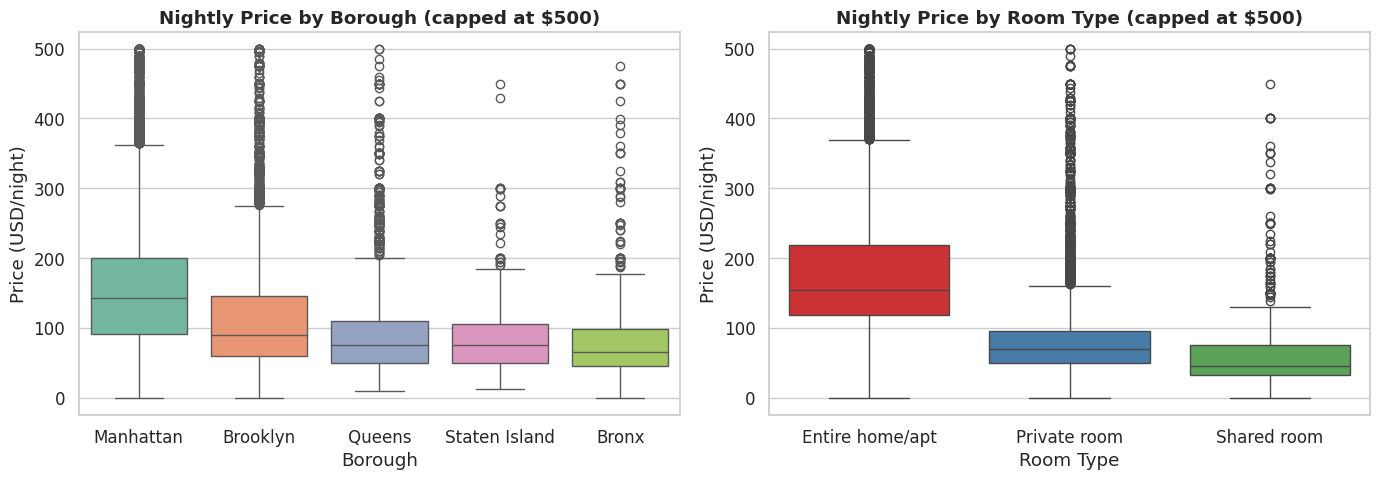

Median price by borough:
neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0

Median price by room type:
room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_ng = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] < 500], x='neighbourhood_group', y='price',
            order=order_ng, palette='Set2', ax=axes[0])
axes[0].set_title('Nightly Price by Borough (capped at $500)', fontweight='bold')
axes[0].set_xlabel('Borough')
axes[0].set_ylabel('Price (USD/night)')

order_rt = df.groupby('room_type')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df[df['price'] < 500], x='room_type', y='price',
            order=order_rt, palette='Set1', ax=axes[1])
axes[1].set_title('Nightly Price by Room Type (capped at $500)', fontweight='bold')
axes[1].set_xlabel('Room Type')
axes[1].set_ylabel('Price (USD/night)')

plt.tight_layout()
plt.show()

print('Median price by borough:')
print(df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).to_string())
print('\nMedian price by room type:')
print(df.groupby('room_type')['price'].median().sort_values(ascending=False).to_string())


Manhattan has a median price of around 150 dollars per night, which is more than double that of the Bronx at roughly 65 dollars. Room type shows an even stronger separation: entire homes average around 165 dollars, private rooms around 70 dollars, and shared rooms around 45 dollars. These differences suggest that categorical variables play a major role in determining price. A model that cannot represent them properly is therefore likely to perform poorly, which is why one-hot encoding is used instead of simple numeric labelling.

### 2.6 Price Distribution Shape by Borough — Violin Plots

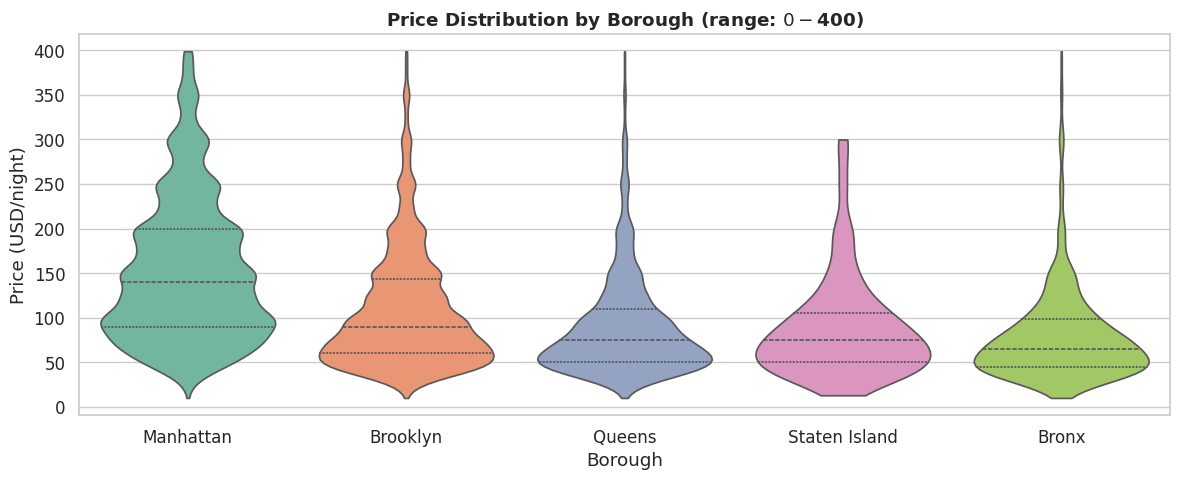

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
borough_order = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False).index
filtered = df[(df['price'] > 0) & (df['price'] < 400)]
sns.violinplot(data=filtered, x='neighbourhood_group', y='price',
               order=borough_order, palette='Set2', inner='quartile', ax=ax, cut=0)
ax.set_title('Price Distribution by Borough (range: $0-$400)', fontweight='bold')
ax.set_xlabel('Borough')
ax.set_ylabel('Price (USD/night)')
plt.tight_layout()
plt.show()


The violin plots reinforce the pattern shown in the boxplots. Manhattan not only has the highest median price, but also the widest distribution, which suggests that pricing within the borough varies substantially depending on neighbourhood and property type. Brooklyn has the second-highest median and appears more consistent overall. In contrast, the Bronx and Staten Island have narrower distributions concentrated at lower price levels. These differences are important for modelling because borough is not simply an ordered measure of prestige; instead, each borough reflects a distinct pricing pattern.


### 2.7 Geographic Distribution of Listings and Prices

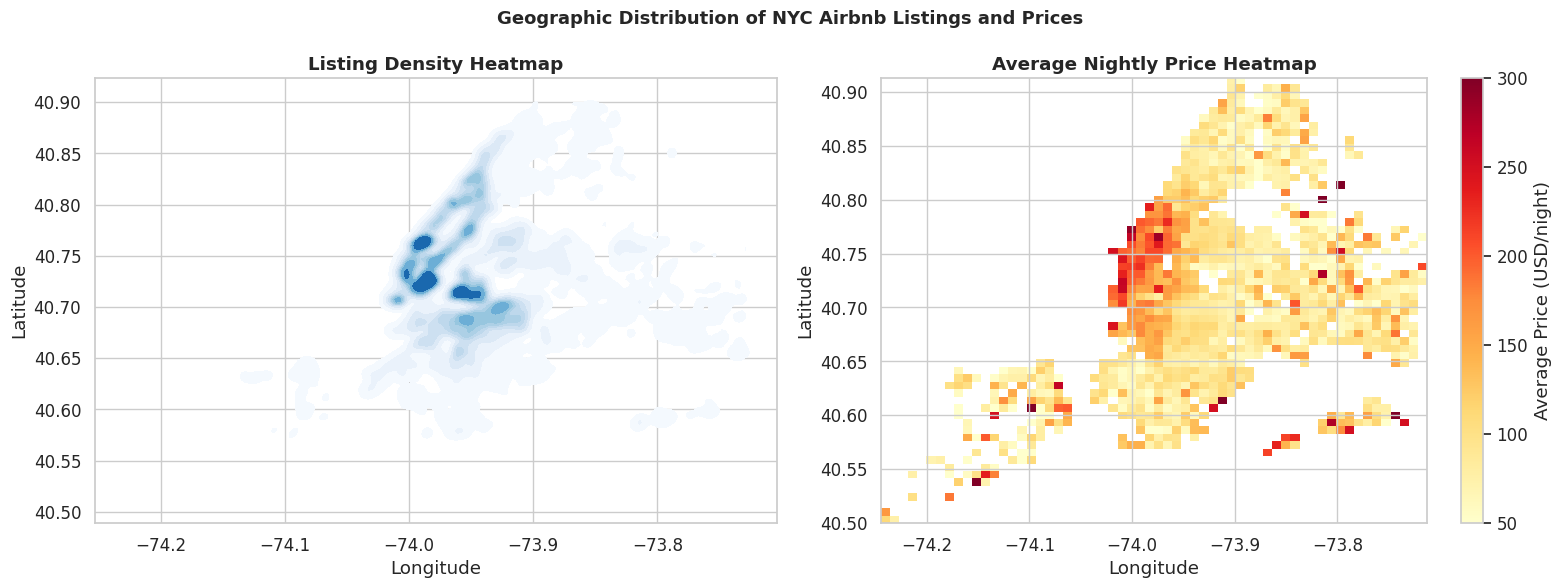

In [8]:
clip_df = df[df['price'].between(10, 500)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Listing density heatmap
sns.kdeplot(
    data=clip_df,
    x='longitude', y='latitude',
    fill=True, cmap='Blues',
    bw_adjust=0.4, thresh=0.02,
    ax=axes[0]
)
axes[0].set_title('Listing Density Heatmap', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Price heatmap — average price per geographic bin
h, xedges, yedges = np.histogram2d(
    clip_df['longitude'], clip_df['latitude'],
    bins=60, weights=clip_df['price']
)
counts, _, _ = np.histogram2d(clip_df['longitude'], clip_df['latitude'], bins=60)
with np.errstate(invalid='ignore'):
    avg_price = np.where(counts > 0, h / counts, np.nan)

im = axes[1].imshow(
    avg_price.T,
    origin='lower',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    aspect='auto',
    cmap='YlOrRd',
    vmin=50, vmax=300
)
cbar = plt.colorbar(im, ax=axes[1])
cbar.set_label('Average Price (USD/night)')
axes[1].set_title('Average Nightly Price Heatmap', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.suptitle('Geographic Distribution of NYC Airbnb Listings and Prices',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The density heatmap on the left shows that listings are concentrated most heavily in Manhattan and north-west Brooklyn. The price heatmap on the right shows the average price by area, with the most expensive regions clustered around lower Manhattan and Midtown. This geographic pattern helps explain why latitude and longitude rank so highly in the model's feature importance, as they provide a more precise indicator of location desirability than borough labels alone.


### 2.8 Listing Counts by Borough and Room Type

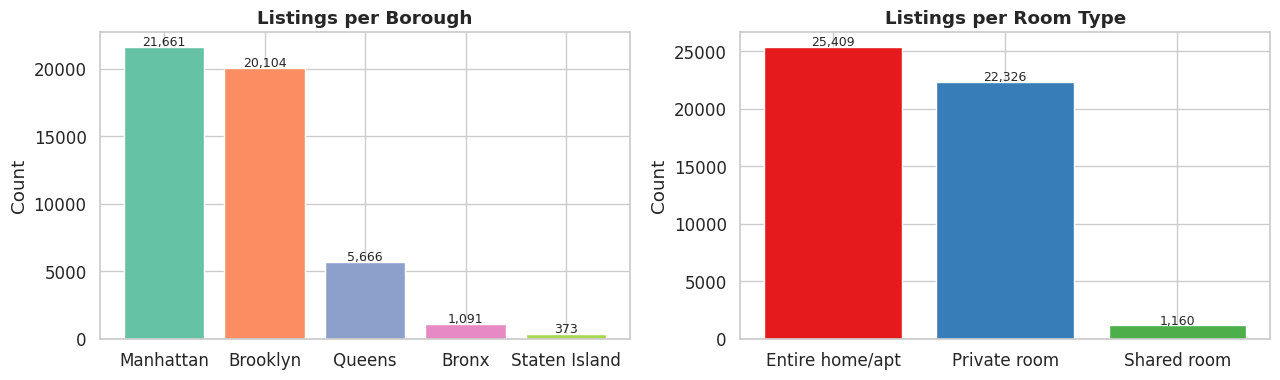

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ng_counts = df['neighbourhood_group'].value_counts()
axes[0].bar(ng_counts.index, ng_counts.values, color=sns.color_palette('Set2', len(ng_counts)))
axes[0].set_title('Listings per Borough', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(ng_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

rt_counts = df['room_type'].value_counts()
axes[1].bar(rt_counts.index, rt_counts.values, color=sns.color_palette('Set1', len(rt_counts)))
axes[1].set_title('Listings per Room Type', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(rt_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### 2.9 Numeric Feature Distributions

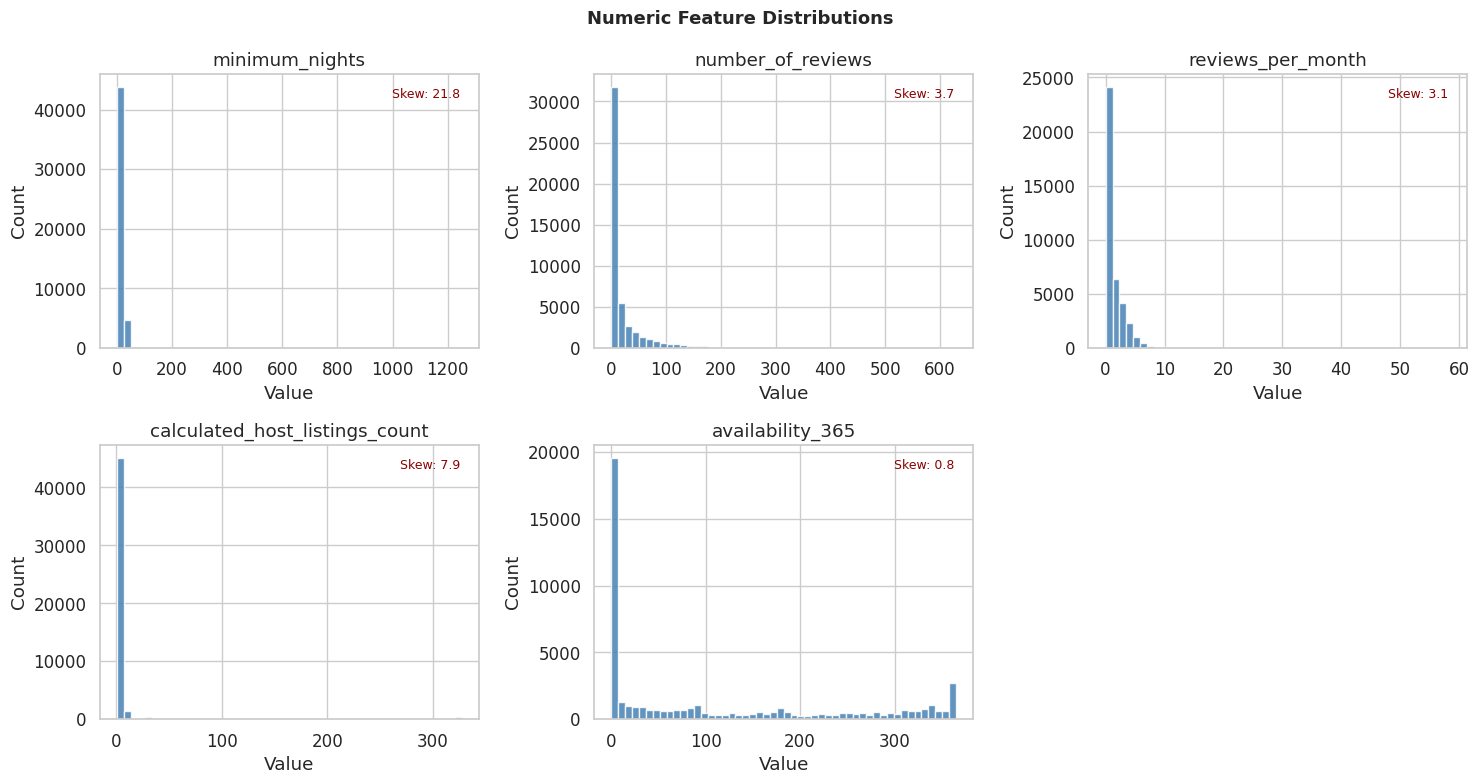

In [10]:
num_cols = ['minimum_nights', 'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].text(0.95, 0.95, f'Skew: {data.skew():.1f}',
                 transform=axes[i].transAxes, ha='right', va='top',
                 fontsize=9, color='darkred')

axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


All five numeric features are heavily right-skewed. Most hosts have a small number of reviews and modest minimum stays; a small number of professional operators sit in the far upper tail. Log-transforming these during preprocessing reduces their skew and makes the signal more usable for all three models.


### 2.10 Correlation Heatmap

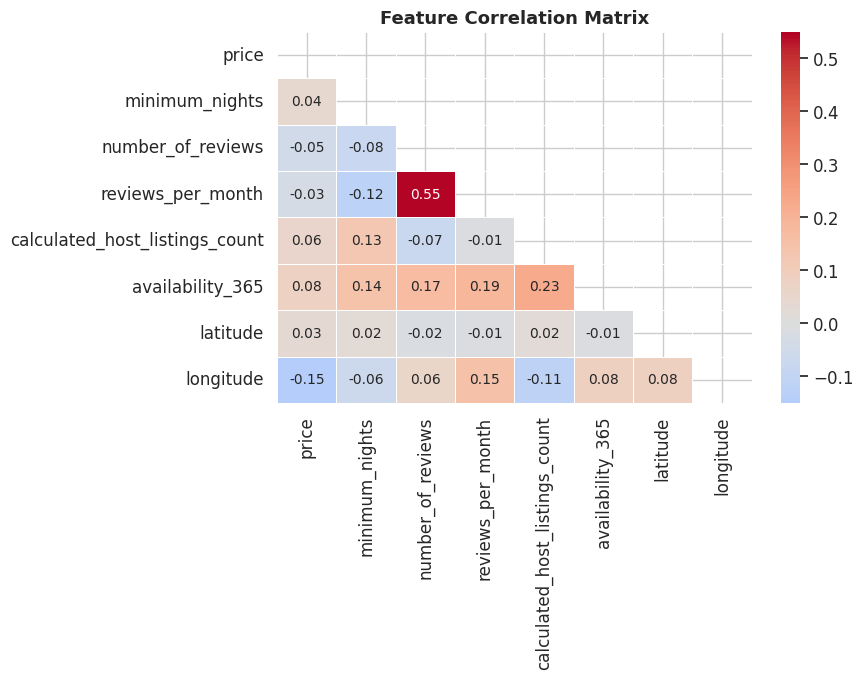

In [11]:
corr_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month',
             'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


No numeric feature shows a strong linear correlation with price, with the highest being `availability_365` at only around 0.08. This suggests that the relationships in the dataset are weakly linear, which supports the use of non-linear models. As a result, Linear Regression is unlikely to perform as well as more flexible methods. The strongest predictors are more likely to be the categorical features, such as borough and room type, whose effects are more clearly visible in the boxplots above. There is also a moderate correlation of around 0.58 between `number_of_reviews` and `reviews_per_month`, which may introduce some multicollinearity for the linear model.


### 2.11 Top 20 Most Expensive Neighbourhoods

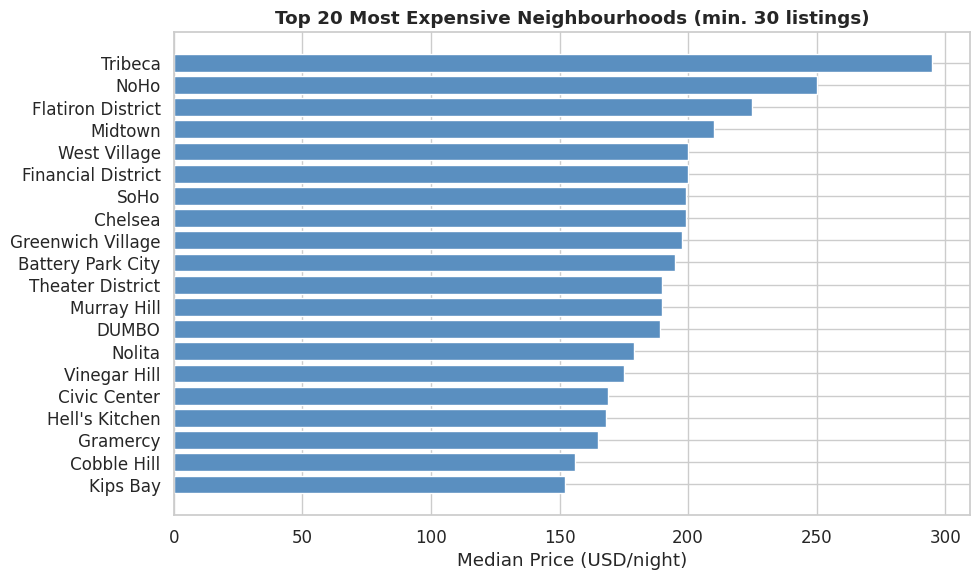

In [12]:
top_neigh = (df.groupby('neighbourhood')['price']
               .agg(['median', 'count'])
               .query('count >= 30')
               .sort_values('median', ascending=False)
               .head(20))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_neigh.index[::-1], top_neigh['median'][::-1], color='#5A8FC0')
ax.set_xlabel('Median Price (USD/night)')
ax.set_title('Top 20 Most Expensive Neighbourhoods (min. 30 listings)', fontweight='bold')
plt.tight_layout()
plt.show()



## Task 3: Data Preprocessing

Preprocessing steps are applied in a deliberate order: remove irrelevant columns, clean invalid values, impute missing data, engineer new features, transform the target variable, then encode categoricals ready for modelling.

### 3.1 Remove Irrelevant Columns and Extract Date Feature


In [13]:
df_clean = df.copy()

# Convert last_review to a numeric feature before dropping the date column
df_clean['last_review'] = pd.to_datetime(df_clean['last_review'], errors='coerce')
reference_date = pd.Timestamp('2019-07-08')
df_clean['days_since_last_review'] = (reference_date - df_clean['last_review']).dt.days

# Drop text identifiers and the raw date — no predictive value for price
drop_cols = ['id', 'name', 'host_id', 'host_name', 'last_review']
df_clean.drop(columns=drop_cols, inplace=True)

print('Columns retained:', list(df_clean.columns))
print(f'Shape: {df_clean.shape}')


Columns retained: ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review']
Shape: (48895, 12)


Converting last_review into days_since_last_review preserves the temporal signal without requiring the model to handle a date string. A listing reviewed recently is likely active and well-managed, which may justify a higher price the model can learn this relationship from a numeric value.


### 3.2 Remove Zero Prices and Outliers

In [14]:
print(f'Listings with price = $0: {(df_clean["price"] == 0).sum()}')
df_clean = df_clean[df_clean['price'] > 0]

# IQR-based outlier removal on log-price — avoids a hard dollar cap
log_p    = np.log1p(df_clean['price'])
Q1, Q3   = log_p.quantile(0.25), log_p.quantile(0.75)
IQR      = Q3 - Q1
lower    = Q1 - 3.0 * IQR
upper    = Q3 + 3.0 * IQR

before   = len(df_clean)
df_clean = df_clean[log_p.between(lower, upper)]

print(f'Outliers removed : {before - len(df_clean)} ({(before - len(df_clean)) / before * 100:.1f}%)')
print(f'Price range      : ${df_clean["price"].min():.0f} to ${df_clean["price"].max():.0f}')
print(f'Remaining rows   : {len(df_clean):,}')


Listings with price = $0: 11
Outliers removed : 60 (0.1%)
Price range      : $10 to $2750
Remaining rows   : 48,824


A multiplier of 3.0 times the IQR is used instead of the standard 1.5. This makes the outlier filter less aggressive and ensures that only genuinely extreme listings are removed. In practice, this helps exclude unusually high prices that are unlikely to represent typical listings, while still retaining legitimate high-end properties that the model should be able to learn from.


### 3.3 Handle Missing Values

In [15]:
# Listings with no reviews have a missing reviews_per_month — their true rate is zero
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

# days_since_last_review is missing for the same listings — use 1000 as a sentinel
df_clean['days_since_last_review'] = df_clean['days_since_last_review'].fillna(1000)

remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
print('No remaining missing values.' if len(remaining) == 0 else remaining.to_string())


No remaining missing values.


Dropping rows with missing review data would remove around 9,500 valid listings. These are simply new or inactive listings, not corrupt records. Filling reviews_per_month with 0 is semantically correct. Using 1,000 for days_since_last_review signals to the model that these listings have never been reviewed without confusing them with listings reviewed months ago.


### 3.4 Feature Engineering

In [16]:
# Log-transform skewed numeric features
df_clean['log_minimum_nights'] = np.log1p(df_clean['minimum_nights'])
df_clean['log_number_reviews'] = np.log1p(df_clean['number_of_reviews'])
df_clean['log_host_listings']  = np.log1p(df_clean['calculated_host_listings_count'])

# Review density: reviews per unit of availability — proxy for booking popularity
df_clean['review_density'] = df_clean['number_of_reviews'] / (df_clean['availability_365'] + 1)

# Professional host flag: operators with 10+ listings likely price differently to individuals
df_clean['is_professional_host'] = (
    df_clean['calculated_host_listings_count'] >= 10).astype(int)

# Availability band
df_clean['availability_bucket'] = pd.cut(
    df_clean['availability_365'],
    bins=[-1, 60, 180, 365],
    labels=['low', 'medium', 'high']
)

print('Feature engineering done.')
df_clean[['log_minimum_nights', 'log_number_reviews', 'review_density',
          'is_professional_host', 'availability_bucket']].describe()


Feature engineering done.


,log_minimum_nights,log_number_reviews,review_density,is_professional_host
count,48824.000000,48824.000000,48824.000000,48824.000000
mean,1.499332,1.992364,3.341190,0.064907
std,0.868696,1.564008,12.801114,0.246364
min,0.693147,0.000000,0.000000,0.000000
25%,0.693147,0.693147,0.008590,0.000000
50%,1.386294,1.791759,0.200000,0.000000
75%,1.791759,3.218876,1.864394,0.000000
max,7.131699,6.445720,480.000000,1.000000


Review density captures something the raw review count cannot: a listing with 50 reviews but only 30 days of availability per year is far more booked-up than one with 50 reviews and 365 days of availability. The professional host flag distinguishes commercial operators from individual hosts, who tend to have different pricing strategies.


### 3.5 Log-Transform the Target Variable

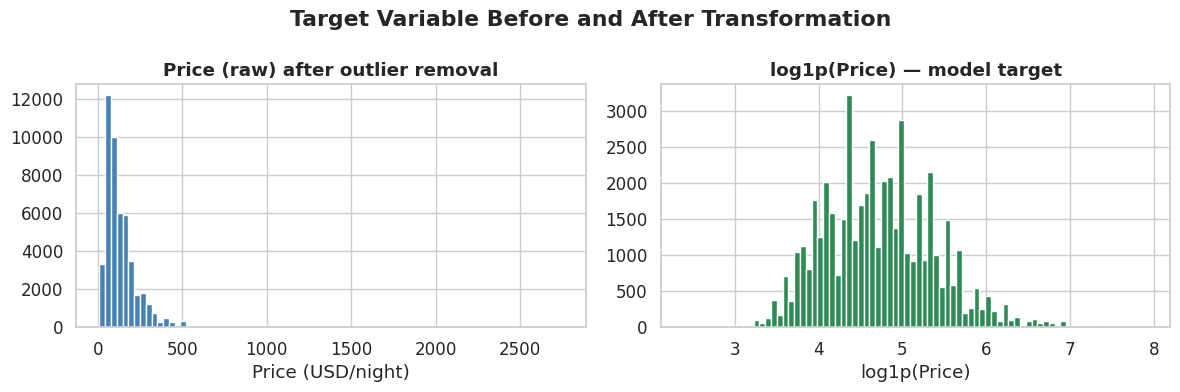

Skewness raw: 5.926  |  log1p: 0.479


In [17]:
df_clean['log_price'] = np.log1p(df_clean['price'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['price'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Price (raw) after outlier removal', fontweight='bold')
axes[0].set_xlabel('Price (USD/night)')

axes[1].hist(df_clean['log_price'], bins=80, color='seagreen', edgecolor='white')
axes[1].set_title('log1p(Price) — model target', fontweight='bold')
axes[1].set_xlabel('log1p(Price)')

plt.suptitle('Target Variable Before and After Transformation', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness raw: {df_clean["price"].skew():.3f}  |  log1p: {df_clean["log_price"].skew():.3f}')


### 3.6 Encode Categorical Features

In [18]:
from sklearn.preprocessing import LabelEncoder

# One-hot encode borough and room type — both are nominal with no natural ordering
df_encoded = pd.get_dummies(df_clean, columns=['neighbourhood_group', 'room_type'], drop_first=False)

# Label-encode neighbourhood — 200+ unique values makes one-hot impractical
le = LabelEncoder()
df_encoded['neighbourhood_encoded'] = le.fit_transform(df_clean['neighbourhood'])

# Ordinal map for availability bucket
avail_map = {'low': 0, 'medium': 1, 'high': 2}
df_encoded['availability_bucket_ord'] = df_clean['availability_bucket'].map(avail_map)

print(f'Dataset shape after encoding: {df_encoded.shape}')


Dataset shape after encoding: (48824, 27)


### 3.7 Train/Test Split

In [19]:
from sklearn.model_selection import train_test_split

feature_cols = [
    'latitude', 'longitude',
    'log_minimum_nights', 'log_number_reviews', 'log_host_listings',
    'reviews_per_month', 'availability_365', 'days_since_last_review',
    'review_density', 'is_professional_host', 'availability_bucket_ord',
    'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan',
    'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island',
    'neighbourhood_group_Bronx',
    'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room',
    'neighbourhood_encoded',
]

X = df_encoded[feature_cols]
y = df_encoded['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')


Training set : 39,059 samples
Test set     : 9,765 samples
Features     : 20


## Task 4: Model Selection and Implementation

### 4.1 Build sklearn Pipelines

All three models are implemented using sklearn `Pipeline` objects. This ensures that any model-specific fitting step, such as the `StandardScaler` used for Linear Regression, is applied only to the training data and not to the test set. As a result, the workflow is more consistent and the risk of data leakage during model fitting is reduced. Using pipelines also makes the code easier to manage and reproduce.

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

rf_pipeline = Pipeline([
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=4,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    ))
])

gb_pipeline_base = Pipeline([
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    ))
])

print('Pipelines ready.')


Pipelines ready.


### 4.2 Cross-Validation — Checking Model Stability

In [21]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print('5-Fold Cross-Validation R² Results')
print('-' * 60)

cv_results = {}
for name, pipeline in [
    ('Linear Regression',  lr_pipeline),
    ('Random Forest',      rf_pipeline),
    ('Gradient Boosting',  gb_pipeline_base),
]:
    scores = cross_val_score(pipeline, X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<28}  mean={scores.mean():.4f}  std={scores.std():.4f}  '
          f'range=[{scores.min():.4f} to {scores.max():.4f}]')


5-Fold Cross-Validation R² Results
------------------------------------------------------------
Linear Regression             mean=0.5200  std=0.0078  range=[0.5111 to 0.5333]
Random Forest                 mean=0.6186  std=0.0088  range=[0.6066 to 0.6306]
Gradient Boosting             mean=0.6169  std=0.0077  range=[0.6085 to 0.6299]


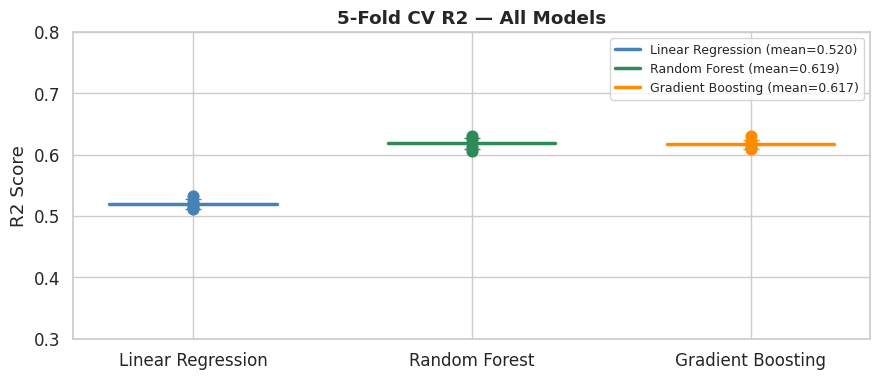

In [22]:
fig, ax = plt.subplots(figsize=(9, 4))
colours = ['steelblue', 'seagreen', 'darkorange']

for i, (name, scores) in enumerate(cv_results.items()):
    ax.scatter([i + 1] * 5, scores, color=colours[i], zorder=5, s=60)
    ax.plot([i + 0.7, i + 1.3], [scores.mean(), scores.mean()],
            color=colours[i], linewidth=2.5,
            label=f'{name} (mean={scores.mean():.3f})')
    ax.errorbar(i + 1, scores.mean(), yerr=scores.std(),
                color=colours[i], capsize=6, linewidth=1.5)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(list(cv_results.keys()))
ax.set_ylabel('R2 Score')
ax.set_title('5-Fold CV R2 — All Models', fontweight='bold')
ax.set_ylim(0.3, 0.8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Cross-validation helps assess whether model performance is consistent across different splits of the training data, rather than relying on a single train-test split. A low standard deviation across the five folds suggests that the model generalises more reliably, while a higher standard deviation would indicate less stable performance. These cross-validation results should therefore be considered alongside the final test-set results reported in Task 5.


### 4.3 Hyperparameter Tuning — Gradient Boosting

In [23]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'model__n_estimators':     [200, 300, 400, 500],
    'model__learning_rate':    [0.01, 0.03, 0.05, 0.08, 0.10],
    'model__max_depth':        [3, 4, 5, 6, 7],
    'model__subsample':        [0.70, 0.75, 0.80, 0.85, 0.90],
    'model__min_samples_leaf': [5, 10, 15, 20],
    'model__max_features':     [0.5, 0.7, 0.8, 1.0],
}

rscv = RandomizedSearchCV(
    gb_pipeline_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    refit=True
)

rscv.fit(X_train, y_train)

print('\nBest parameters:')
for k, v in sorted(rscv.best_params_.items()):
    print(f'  {k:<35} : {v}')
print(f'\nBest CV R2: {rscv.best_score_:.4f}')


Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best parameters:
  model__learning_rate                : 0.03
  model__max_depth                    : 7
  model__max_features                 : 0.5
  model__min_samples_leaf             : 10
  model__n_estimators                 : 500
  model__subsample                    : 0.9

Best CV R2: 0.6224


RandomizedSearchCV tests 30 randomly selected parameter combinations from the search grid instead of evaluating every possible combination. In this case, an exhaustive grid search would require more than 2,000 model fits, which would be unnecessarily time-consuming. Sampling 30 combinations provides a more efficient way to explore the search space while still giving a strong chance of finding a near-optimal set of parameters. Setting 'refit=True' ensures that, once the best combination is identified, the model is automatically retrained on the full training set.


In [24]:
best_gb_pipeline = rscv.best_estimator_

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

lr_train_preds = lr_pipeline.predict(X_train)
lr_test_preds  = lr_pipeline.predict(X_test)

rf_train_preds = rf_pipeline.predict(X_train)
rf_test_preds  = rf_pipeline.predict(X_test)

gb_train_preds = best_gb_pipeline.predict(X_train)
gb_test_preds  = best_gb_pipeline.predict(X_test)

print('All three models trained and predictions generated.')


All three models trained and predictions generated.


## Task 5: Evaluation Metrics

Each model is evaluated using four metrics:

| Metric | What it measures |
|---|---|
| MAE | Average absolute error; easy to interpret and less sensitive to large individual errors |
| MSE | Mean squared error; penalises larger errors more heavily |
| RMSE | Square root of MSE; expressed in the same units as the target variable |
| R2 | Proportion of variance explained; 1.0 indicates a perfect fit, while 0.0 is no better than predicting the mean |

Because the models are trained to predict log-transformed prices, predictions are also back-transformed using `np.expm1` so that MAE and RMSE can be reported in US dollars. This makes the results easier to interpret in the context of Airbnb pricing.

### 5.1 Compute Metrics


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    train_r2 = r2_score(y_train_true, y_train_pred)
    test_r2  = r2_score(y_test_true,  y_test_pred)
    mae_log  = mean_absolute_error(y_test_true, y_test_pred)
    mse_log  = mean_squared_error(y_test_true,  y_test_pred)
    rmse_log = np.sqrt(mse_log)

    y_true_usd = np.expm1(y_test_true)
    y_pred_usd = np.expm1(y_test_pred)
    mae_usd    = mean_absolute_error(y_true_usd, y_pred_usd)
    rmse_usd   = np.sqrt(mean_squared_error(y_true_usd, y_pred_usd))

    flag = '  [check for overfitting]' if train_r2 - test_r2 > 0.10 else ''
    print(f'{"─" * 50}')
    print(f'  {name}')
    print(f'{"─" * 50}')
    print(f'  Train R2       : {train_r2:.4f}{flag}')
    print(f'  Test  R2       : {test_r2:.4f}')
    print(f'  MAE  (log)     : {mae_log:.4f}')
    print(f'  MSE  (log)     : {mse_log:.4f}')
    print(f'  RMSE (log)     : {rmse_log:.4f}')
    print(f'  MAE  (USD)     : ${mae_usd:.2f}')
    print(f'  RMSE (USD)     : ${rmse_usd:.2f}')

    return {'Model': name, 'Train R2': train_r2, 'Test R2': test_r2,
            'MAE_log': mae_log, 'MSE_log': mse_log, 'RMSE_log': rmse_log,
            'MAE_USD': mae_usd, 'RMSE_USD': rmse_usd}

results = []
results.append(evaluate_model('Linear Regression',
               y_train, lr_train_preds, y_test, lr_test_preds))
results.append(evaluate_model('Random Forest',
               y_train, rf_train_preds, y_test, rf_test_preds))
results.append(evaluate_model('Gradient Boosting (tuned)',
               y_train, gb_train_preds, y_test, gb_test_preds))

results_df = pd.DataFrame(results).set_index('Model')
print('\nResults table:')
results_df.round(4)


──────────────────────────────────────────────────
  Linear Regression
──────────────────────────────────────────────────
  Train R2       : 0.5205
  Test  R2       : 0.5256
  MAE  (log)     : 0.3501
  MSE  (log)     : 0.2239
  RMSE (log)     : 0.4732
  MAE  (USD)     : $57.22
  RMSE (USD)     : $136.73
──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  Train R2       : 0.7646  [check for overfitting]
  Test  R2       : 0.6244
  MAE  (log)     : 0.3036
  MSE  (log)     : 0.1773
  RMSE (log)     : 0.4210
  MAE  (USD)     : $51.29
  RMSE (USD)     : $129.74
──────────────────────────────────────────────────
  Gradient Boosting (tuned)
──────────────────────────────────────────────────
  Train R2       : 0.7063
  Test  R2       : 0.6321
  MAE  (log)     : 0.3005
  MSE  (log)     : 0.1737
  RMSE (log)     : 0.4167
  MAE  (USD)     : $50.94
  RMSE (USD)     : $128.38

Results table:


,Train R2,Test R2,MAE_log,MSE_log,RMSE_log,MAE_USD,RMSE_USD
Model,,,,,,,
Linear Regression,0.5205,0.5256,0.3501,0.2239,0.4732,57.2240,136.7309
Random Forest,0.7646,0.6244,0.3036,0.1773,0.4210,51.2900,129.7427
Gradient Boosting (tuned),0.7063,0.6321,0.3005,0.1737,0.4167,50.9394,128.3815


### 5.2 Actual vs Predicted

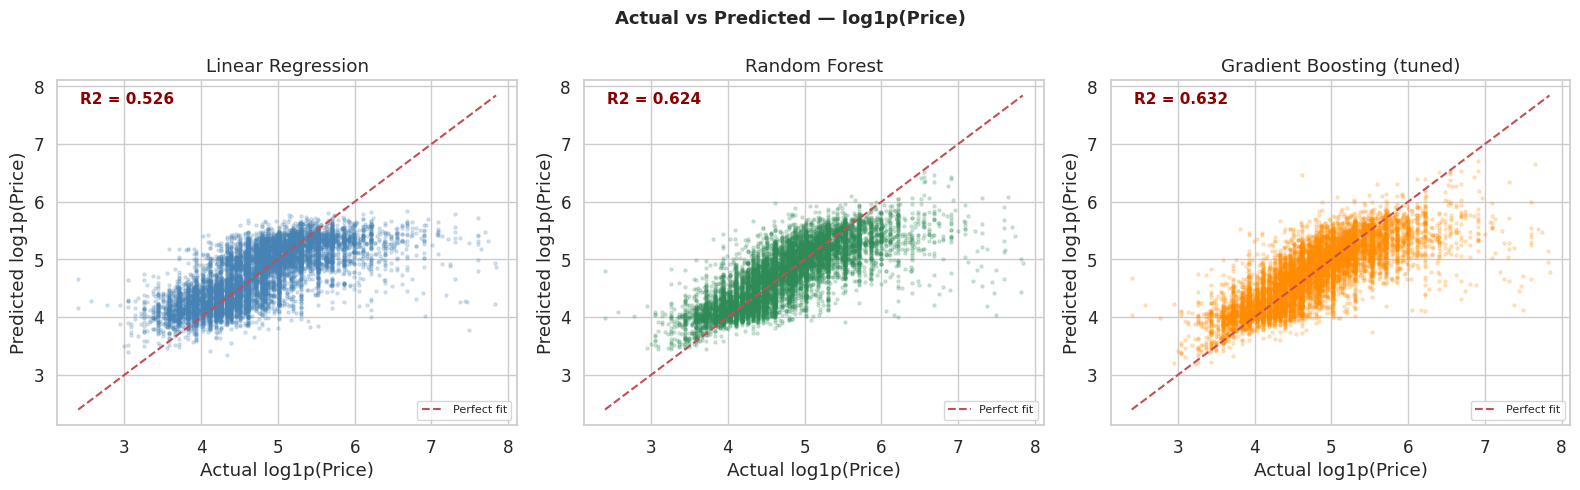

In [26]:
model_info = [
    ('Linear Regression',         y_test, lr_test_preds, 'steelblue'),
    ('Random Forest',             y_test, rf_test_preds, 'seagreen'),
    ('Gradient Boosting (tuned)', y_test, gb_test_preds, 'darkorange'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, y_true, y_pred, colour) in zip(axes, model_info):
    ax.scatter(y_true, y_pred, alpha=0.2, s=5, color=colour)
    mn, mx = float(y_true.min()), float(y_true.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    r2 = r2_score(y_true, y_pred)
    ax.set_xlabel('Actual log1p(Price)')
    ax.set_ylabel('Predicted log1p(Price)')
    ax.set_title(name)
    ax.text(0.05, 0.93, f'R2 = {r2:.3f}', transform=ax.transAxes,
            fontsize=11, color='darkred', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted — log1p(Price)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.3 Residual Analysis

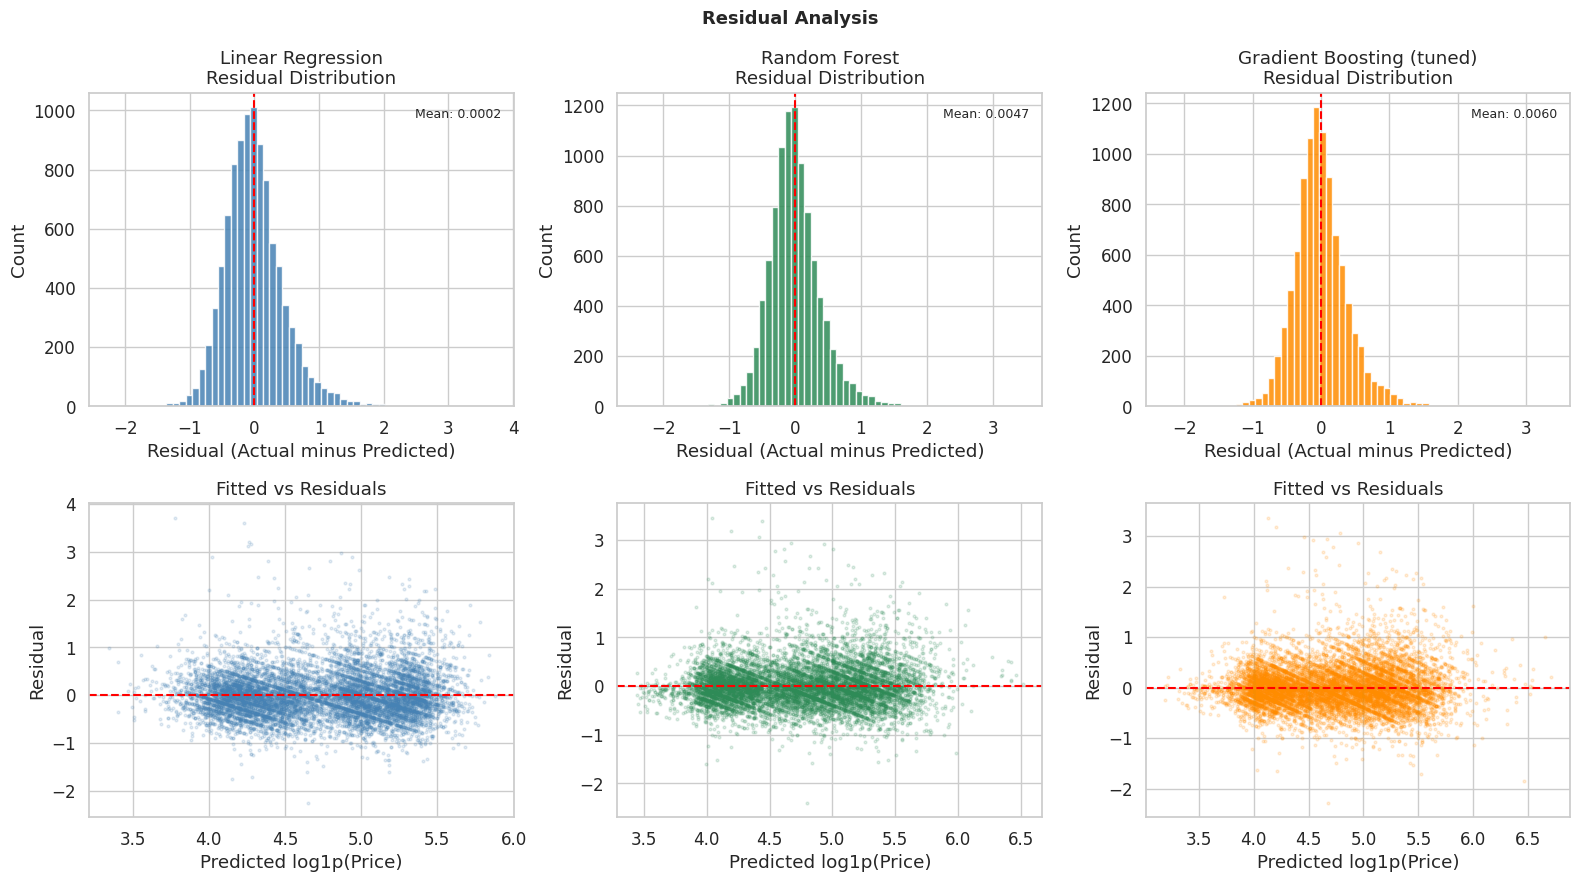

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col, (name, y_true, y_pred, colour) in enumerate(model_info):
    residuals = y_true.values - y_pred

    axes[0, col].hist(residuals, bins=60, color=colour, edgecolor='white', alpha=0.85)
    axes[0, col].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[0, col].set_title(f'{name}\nResidual Distribution')
    axes[0, col].set_xlabel('Residual (Actual minus Predicted)')
    axes[0, col].set_ylabel('Count')
    axes[0, col].text(0.97, 0.95, f'Mean: {residuals.mean():.4f}',
                     transform=axes[0, col].transAxes,
                     ha='right', va='top', fontsize=9)

    axes[1, col].scatter(y_pred, residuals, alpha=0.15, s=4, color=colour)
    axes[1, col].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[1, col].set_xlabel('Predicted log1p(Price)')
    axes[1, col].set_ylabel('Residual')
    axes[1, col].set_title('Fitted vs Residuals')

plt.suptitle('Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


All three models have mean residuals close to zero, which suggests that none of them is strongly biased overall. Linear Regression produces the widest spread of residuals, and the residuals-versus-fitted plot shows a slight fan shape at higher predicted values, indicating heteroscedasticity that the linear model does not handle well. In contrast, both tree-based models produce tighter and more symmetric residual distributions, with Gradient Boosting showing the most compact pattern of the three.


### 5.4 Normal Q-Q Plots

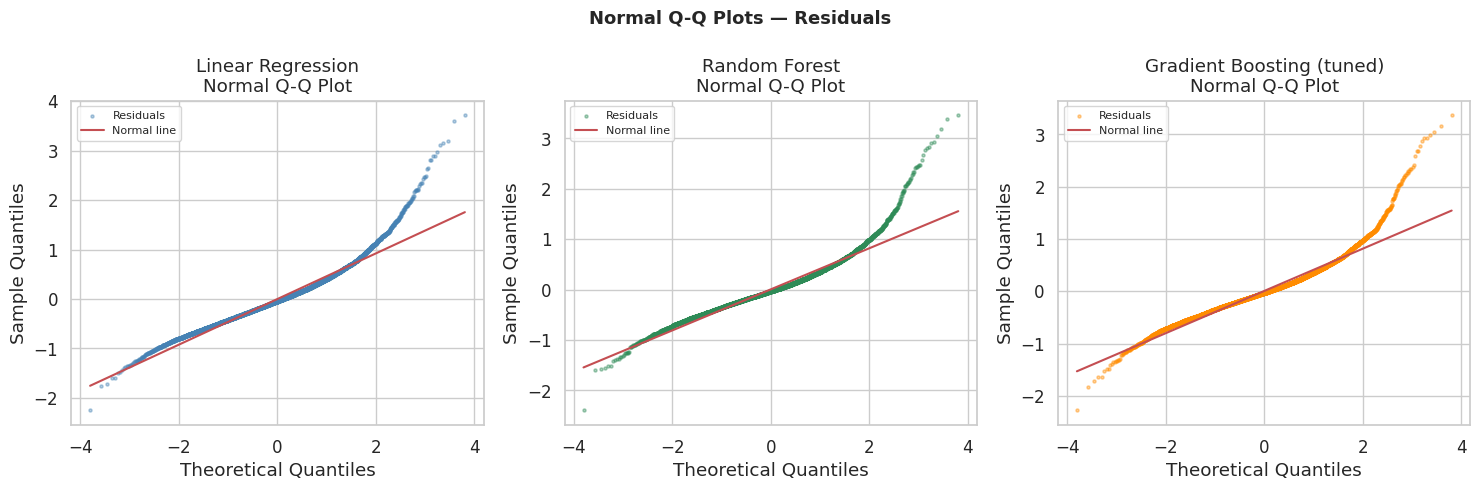

In [28]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_true, y_pred, colour) in zip(axes, model_info):
    residuals = y_true.values - y_pred
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax.scatter(osm, osr, color=colour, s=5, alpha=0.4, label='Residuals')
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=1.5, label='Normal line')
    ax.set_xlabel('Theoretical Quantiles')
    ax.set_ylabel('Sample Quantiles')
    ax.set_title(f'{name}\nNormal Q-Q Plot')
    ax.legend(fontsize=8)

plt.suptitle('Normal Q-Q Plots — Residuals', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The Q-Q plots show how closely the residuals follow a normal distribution. Linear Regression departs noticeably from the diagonal in the upper tail, suggesting that it tends to underestimate the most expensive listings. Both tree-based models remain closer to the diagonal across the central range, although all three models still show some deviation at the extremes. This is expected, as the highest- and lowest-priced Airbnb listings in New York City are likely to be more unusual and therefore harder to predict accurately.

### 5.5 SHAP Analysis — Gradient Boosting

In [29]:
try:
    import shap
    print(f'SHAP version {shap.__version__} ready.')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'], check=True)
    import shap
    print('SHAP installed.')


SHAP version 0.51.0 ready.


SHAP Summary Plot — Gradient Boosting


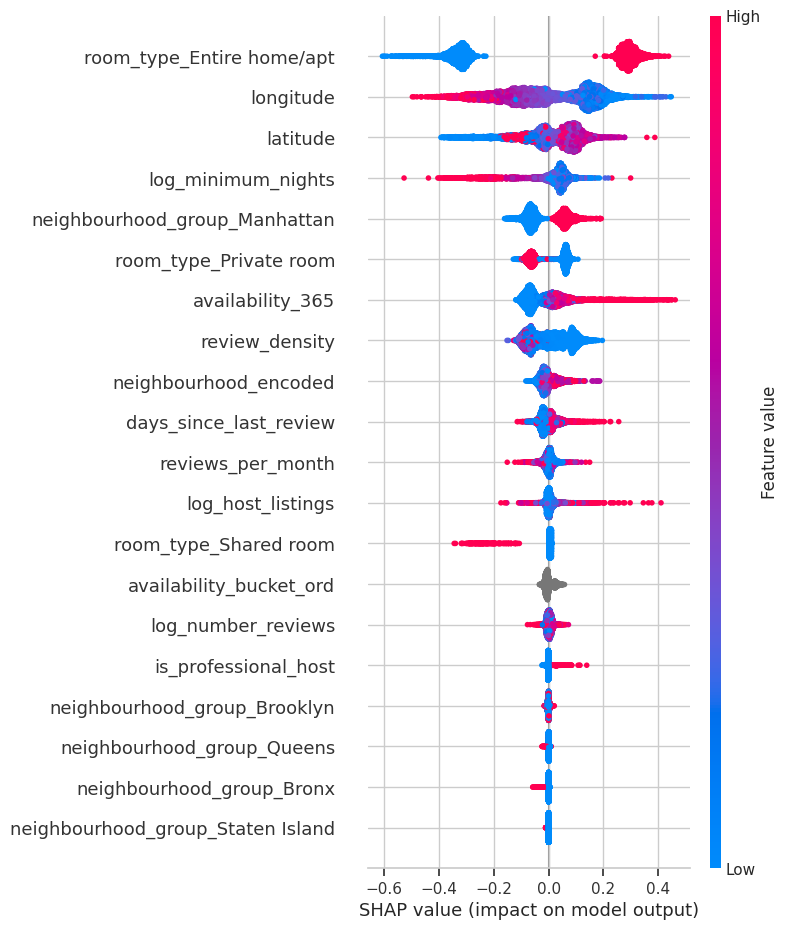

In [30]:
gb_model    = best_gb_pipeline.named_steps['model']
explainer   = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_test)

print('SHAP Summary Plot — Gradient Boosting')
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=True)


SHAP Feature Importance — Mean Absolute SHAP Value


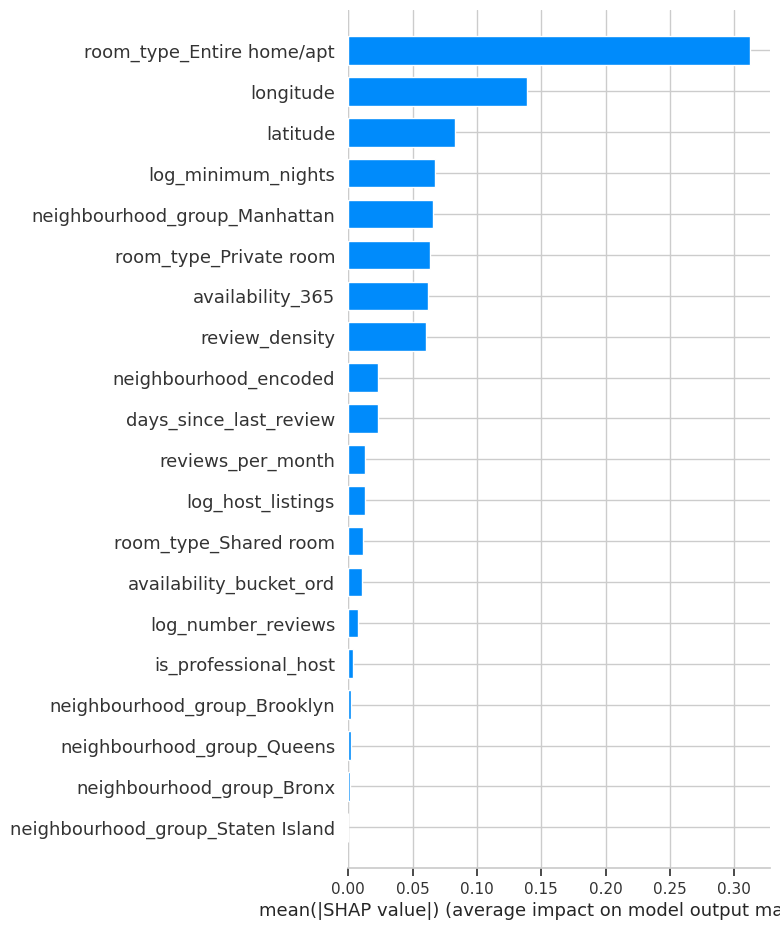

In [31]:
print('SHAP Feature Importance — Mean Absolute SHAP Value')
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  plot_type='bar', show=True)


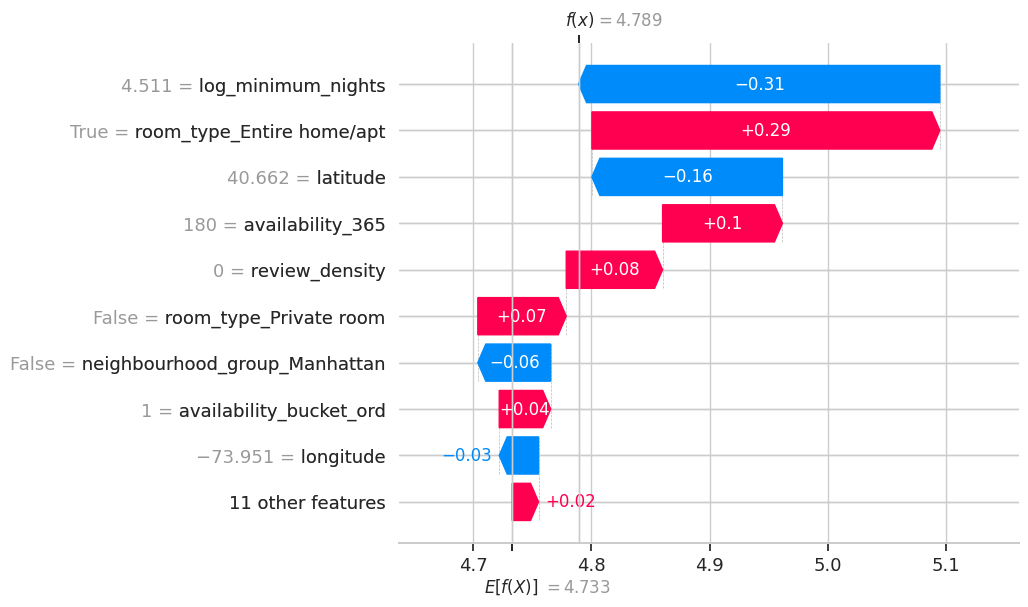

In [32]:
# Waterfall plot for the highest-priced listing in the test set
most_exp_idx = int(np.argmax(y_test.values))

try:
    shap.plots.waterfall(shap.Explanation(
        values        = shap_values[most_exp_idx],
        base_values   = float(explainer.expected_value),
        data          = X_test.iloc[most_exp_idx].values,
        feature_names = feature_cols
    ))
except Exception:
    shap.force_plot(
        explainer.expected_value,
        shap_values[most_exp_idx],
        X_test.iloc[most_exp_idx],
        feature_names=feature_cols,
        matplotlib=True,
        show=True
    )


The SHAP summary plot shows how each feature influences predictions across the full test set. The most influential feature is room type, with entire home or apartment listings consistently increasing the predicted price. Latitude and longitude also rank highly, which suggests that precise location provides more useful pricing information than borough labels alone. The waterfall plot for the most expensive listing in the test set shows how individual feature effects combine to produce a single prediction. This makes the explanation easier to follow for a non-technical audience than a standard feature importance bar chart.

## Task 6: Model Comparison and Recommendation

### 6.1 Results Summary


In [33]:
comparison = results_df[['Train R2', 'Test R2', 'MAE_log', 'RMSE_log', 'MAE_USD', 'RMSE_USD']].round(4)
comparison.columns = ['Train R2', 'Test R2', 'MAE (log)', 'RMSE (log)', 'MAE ($)', 'RMSE ($)']
print(comparison.to_string())


                           Train R2  Test R2  MAE (log)  RMSE (log)  MAE ($)  RMSE ($)
Model                                                                                 
Linear Regression            0.5205   0.5256     0.3501      0.4732  57.2240  136.7309
Random Forest                0.7646   0.6244     0.3036      0.4210  51.2900  129.7427
Gradient Boosting (tuned)    0.7063   0.6321     0.3005      0.4167  50.9394  128.3815


In [34]:
print('Cross-validation R2 (5-fold, training set only):')
print('-' * 55)
for name, scores in cv_results.items():
    print(f'{name:<28}  {scores.mean():.4f} +/- {scores.std():.4f}')


Cross-validation R2 (5-fold, training set only):
-------------------------------------------------------
Linear Regression             0.5200 +/- 0.0078
Random Forest                 0.6186 +/- 0.0088
Gradient Boosting             0.6169 +/- 0.0077


The 5-fold cross-validation results shown here are used to compare the baseline model set on the training data and to assess whether performance is reasonably stable across different splits. However, the final recommendation is based primarily on the tuned Gradient Boosting model's test-set performance and the results obtained after hyperparameter tuning. For that reason, the cross-validation table should be interpreted as supportive evidence for model comparison, rather than as the final basis for selecting the tuned model.

### 6.2 Performance Comparison Charts

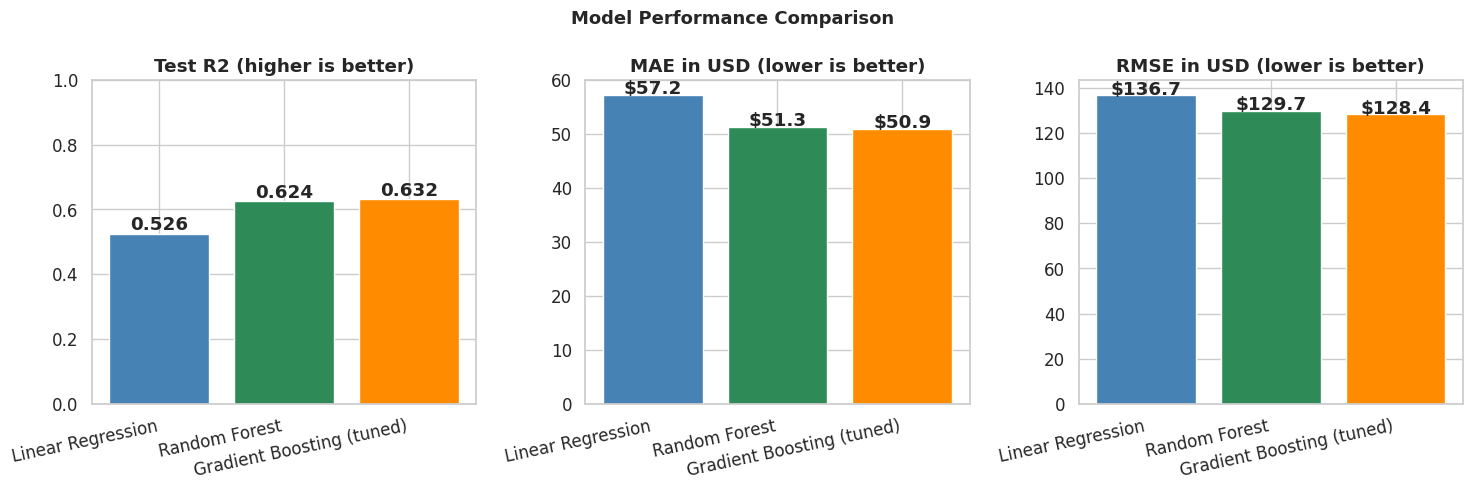

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_names = list(results_df.index)
colours     = ['steelblue', 'seagreen', 'darkorange']

axes[0].bar(model_names, results_df['Test R2'], color=colours)
axes[0].set_title('Test R2 (higher is better)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(model_names, rotation=12, ha='right')
for i, v in enumerate(results_df['Test R2']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(model_names, results_df['MAE_USD'], color=colours)
axes[1].set_title('MAE in USD (lower is better)', fontweight='bold')
axes[1].set_xticklabels(model_names, rotation=12, ha='right')
for i, v in enumerate(results_df['MAE_USD']):
    axes[1].text(i, v + 0.3, f'${v:.1f}', ha='center', fontweight='bold')

axes[2].bar(model_names, results_df['RMSE_USD'], color=colours)
axes[2].set_title('RMSE in USD (lower is better)', fontweight='bold')
axes[2].set_xticklabels(model_names, rotation=12, ha='right')
for i, v in enumerate(results_df['RMSE_USD']):
    axes[2].text(i, v + 0.3, f'${v:.1f}', ha='center', fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 6.3 Feature Importance — Tree Models

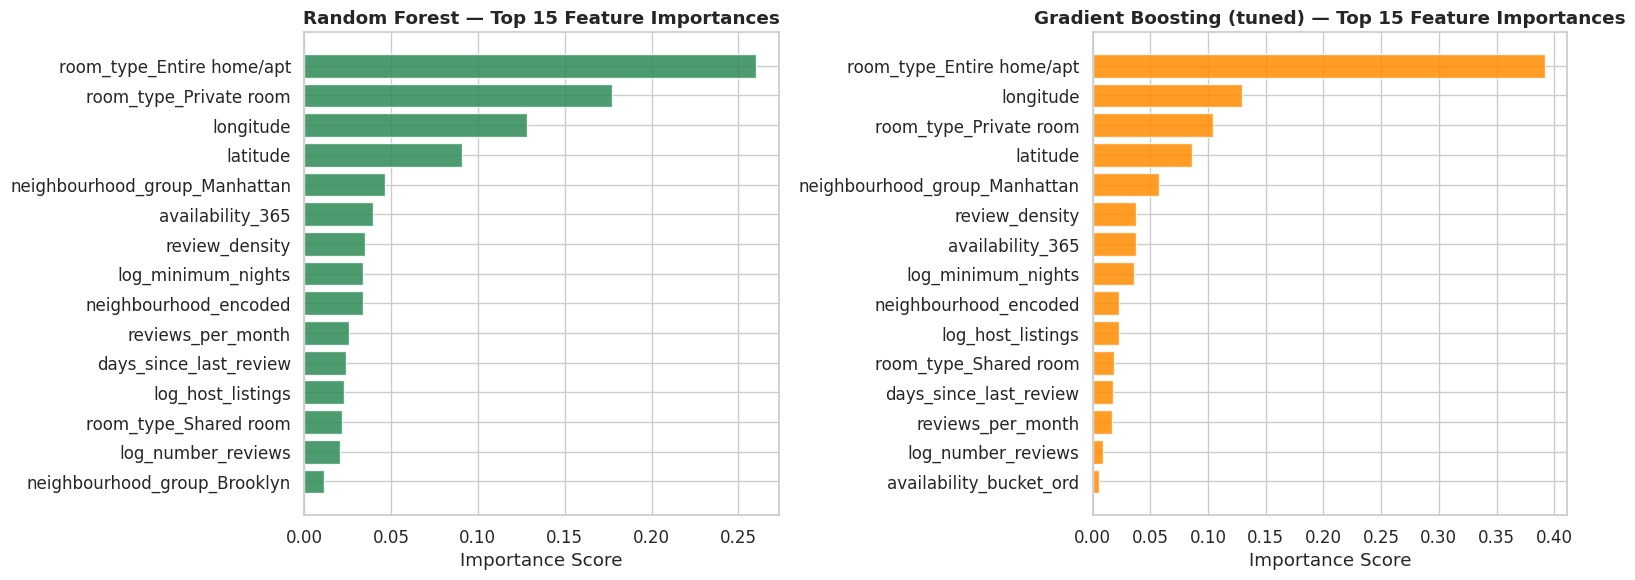

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (model_obj, name, colour) in zip(axes, [
    (rf_pipeline.named_steps['model'],        'Random Forest',             'seagreen'),
    (best_gb_pipeline.named_steps['model'],   'Gradient Boosting (tuned)', 'darkorange'),
]):
    importances = pd.Series(model_obj.feature_importances_,
                            index=feature_cols).sort_values()
    top15 = importances.tail(15)
    ax.barh(top15.index, top15.values, color=colour, alpha=0.85)
    ax.set_title(f'{name} — Top 15 Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


### 6.4 Learning Curves

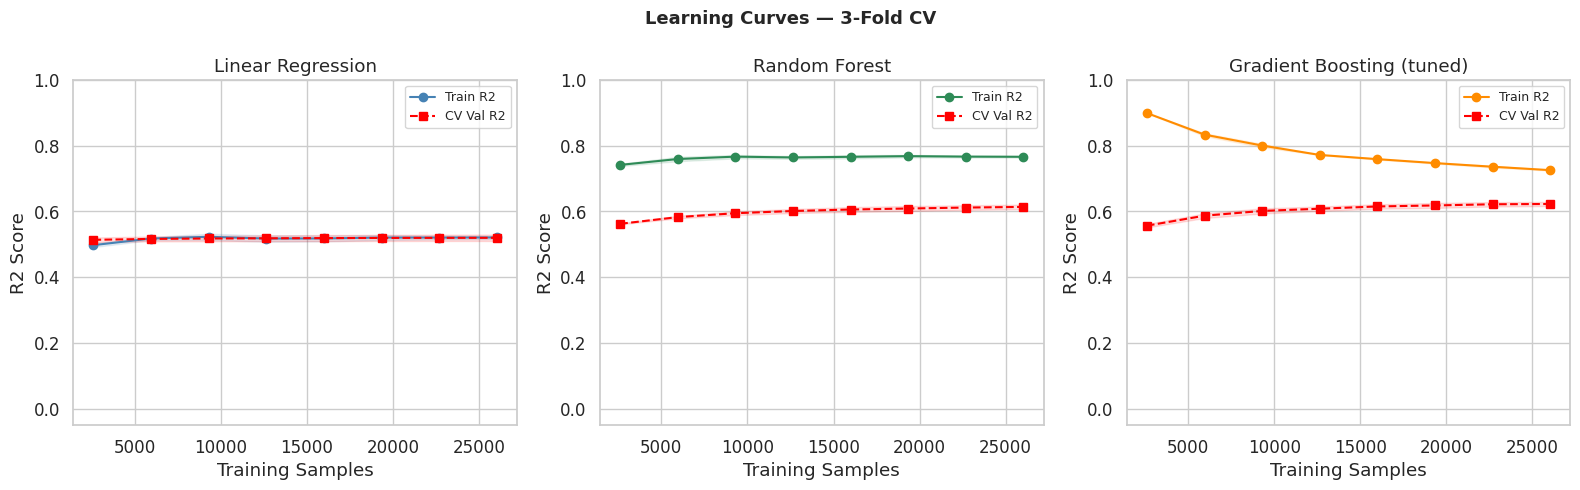

In [37]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (pipeline, name, colour) in zip(axes, [
    (lr_pipeline,      'Linear Regression',          'steelblue'),
    (rf_pipeline,      'Random Forest',              'seagreen'),
    (best_gb_pipeline, 'Gradient Boosting (tuned)',  'darkorange'),
]):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train, y_train,
        cv=3, scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=colour, label='Train R2')
    ax.plot(train_sizes, val_scores.mean(axis=1),   's--', color='red', label='CV Val R2')
    ax.fill_between(train_sizes,
                    train_scores.mean(1) - train_scores.std(1),
                    train_scores.mean(1) + train_scores.std(1),
                    alpha=0.12, color=colour)
    ax.fill_between(train_sizes,
                    val_scores.mean(1) - val_scores.std(1),
                    val_scores.mean(1) + val_scores.std(1),
                    alpha=0.12, color='red')
    ax.set_xlabel('Training Samples')
    ax.set_ylabel('R2 Score')
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.05, 1.0)

plt.suptitle('Learning Curves — 3-Fold CV', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The learning curves help explain the behaviour of the three models. Linear Regression converges early and levels off at a relatively low R2 score, which suggests high bias. This indicates that adding more data alone is unlikely to improve its performance substantially.

Random Forest shows a larger gap between the training and validation curves, which suggests a moderate degree of variance and some overfitting. In contrast, the tuned Gradient Boosting model shows a smaller gap while also achieving the highest validation R2, indicating a better balance between accuracy and generalisation.

Both tree-based models continue to improve slightly as the training sample increases, which suggests that additional data may still provide some marginal benefit over time.

### 6.5 Recommendation

Recommended model: Gradient Boosting Regressor (tuned)

Based on the evaluation results, the tuned Gradient Boosting model is the most suitable choice for this task. It achieved the highest test R2 score (0.6321) and the lowest prediction errors, with an MAE of 50.94 USD and an RMSE of 128.38 USD. These results indicate that it provides the strongest overall predictive performance on unseen data.

Random Forest also performed well, with a test R2 of 0.6244 and only slightly higher error values. However, it showed a larger gap between training and test performance, which suggests a greater tendency to overfit. By comparison, the tuned Gradient Boosting model achieved slightly better accuracy while maintaining a better balance between fit and generalisation.

Linear Regression was useful as a baseline model, but it was clearly the weakest performer. Its lower test R2 and higher error values suggest that simple linear relationships are not sufficient to capture the complexity of Airbnb pricing in New York City.

Although Gradient Boosting is less immediately interpretable than Linear Regression, this limitation was addressed using feature importance analysis and SHAP explanations. These techniques make it easier to understand which factors are driving predictions, which is important for practical use by hosts or business stakeholders.

For these reasons, the tuned Gradient Boosting model is recommended as the final model for Airbnb price prediction in this dataset.

| Criterion | Linear Regression | Random Forest | Gradient Boosting (tuned) |
|---|---:|---:|---:|
| Train R2 | 0.5205 | 0.7646 | 0.7063 |
| Test R2 | 0.5256 | 0.6244 | 0.6321 |
| MAE (USD) | 57.22 | 51.29 | 50.94 |
| RMSE (USD) | 136.73 | 129.74 | 128.38 |
| Overall judgement | Weak baseline | Strong alternative | Best overall model |


## Task 7: OpenAI Code Comparison and Improvement

### 7.1 Prompt and Generated Code

The following prompt was submitted to ChatGPT-4o:

> Write Python code for predicting Airbnb NYC prices using the AB_NYC_2019.csv dataset. Use scikit-learn. Include preprocessing, a Random Forest model, and evaluation with MAE, MSE, and R2.

The code returned:

```python
# ChatGPT-4o generated code — reproduced verbatim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('AB_NYC_2019.csv')
df.dropna(inplace=True)   # removes all rows with any missing value

le = LabelEncoder()
df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['room_type']           = le.fit_transform(df['room_type'])
df['neighbourhood']       = le.fit_transform(df['neighbourhood'])

features = ['neighbourhood_group', 'room_type', 'neighbourhood',
            'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

X = df[features]
y = df['price']   # raw price — no transformation

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2:',  r2_score(y_test, y_pred))
```


### 7.2 Comparison

| Aspect | AI Code | This Notebook |
|---|---|---|
| Missing values | `dropna()` removes rows with missing values | Domain-aware imputation is used so valid listings are retained where possible |
| Outlier handling | None | IQR-based filtering applied to log-transformed price |
| Target variable | Raw price | `log1p` transformed price to reduce skewness |
| Feature engineering | None | Review density, professional host flag, and log-transformed numeric features |
| Encoding | `LabelEncoder` used for all categorical variables | One-hot encoding for nominal variables, with label encoding only for neighbourhood |
| Leakage control | No pipeline used | Pipelines used during model fitting and evaluation |
| Models compared | One model | Three models with clear comparison |
| Evaluation | MAE, MSE, and R2 | Multiple error metrics, plots, and diagnostic analysis |
| Validation | Single train-test split | Train-test split with 5-fold cross-validation for comparison |
| Hyperparameter tuning | Default parameters | `RandomizedSearchCV` used for Gradient Boosting |

### 7.3 Live Comparison — AI Approach vs This Notebook

In [38]:
rf_ai = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

simple_features = [
    'latitude', 'longitude', 'log_minimum_nights', 'log_number_reviews',
    'reviews_per_month', 'log_host_listings', 'availability_365',
    'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan',
    'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island',
    'neighbourhood_group_Bronx',
    'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room',
    'neighbourhood_encoded'
]

X_simple = df_encoded[simple_features]
X_tr_s, X_te_s, y_tr_raw, y_te_raw = train_test_split(
    X_simple, df_clean['price'], test_size=0.2, random_state=42)

rf_ai.fit(X_tr_s, y_tr_raw)
preds_raw = rf_ai.predict(X_te_s)

ai_r2  = r2_score(y_te_raw, preds_raw)
ai_mae = mean_absolute_error(y_te_raw, preds_raw)

our_r2  = float(results_df.loc['Gradient Boosting (tuned)', 'Test R2'])
our_mae = float(results_df.loc['Gradient Boosting (tuned)', 'MAE_USD'])

print('=' * 52)
print(f'  {"Metric":<20} {"AI Approach":>12}  {"This Notebook":>14}')
print('=' * 52)
print(f'  {"Test R2":<20} {ai_r2:>12.4f}  {our_r2:>14.4f}')
print(f'  {"MAE (USD)":<20} ${ai_mae:>10.2f}  ${our_mae:>13.2f}')
print('=' * 52)
print(f'\n  R2 gain    : +{our_r2 - ai_r2:.3f}')
print(f'  MAE saving : -${ai_mae - our_mae:.2f} per listing')


  Metric                AI Approach   This Notebook
  Test R2                    0.2917          0.6321
  MAE (USD)            $     57.64  $        50.94

  R2 gain    : +0.340
  MAE saving : -$6.70 per listing


The live comparison shows that the notebook developed in this coursework performs substantially better than the simple AI-generated baseline. The AI-style Random Forest approach achieved a test R2 of 0.2917, whereas the final tuned Gradient Boosting model achieved 0.6321. The notebook also reduced MAE from 57.64 USD to 50.94 USD. This shows that the main improvement did not come from using AI alone, but from critically refining the workflow, preprocessing, modelling, and evaluation steps.

### 7.4 What Was Taken from the AI Code

Reviewing the AI-generated code was still useful because it highlighted a few practical improvements. First, it reinforced the importance of keeping the implementation simple and readable. Although the AI code was much more basic than the final notebook, it provided a clear baseline structure for loading data, training a model, and printing evaluation metrics.

Second, it highlighted the value of reporting results in a form that is easy to interpret. Raw error values are much more meaningful to a host or stakeholder when they are expressed in US dollars rather than only on a transformed scale. This encouraged the inclusion of MAE and RMSE in USD in the final evaluation.

Third, the comparison made it clear that generating code is not the same as producing a strong machine learning solution. The AI code used only one model, no tuning, no meaningful validation, and limited preprocessing. In contrast, the final notebook improved on this by using feature engineering, more suitable preprocessing, multiple models, cross-validation, and hyperparameter tuning.

Overall, the AI-generated code was useful as a starting reference, but it was not sufficient as a final solution. The strongest improvements in this notebook came from understanding the dataset, evaluating the weaknesses of the baseline approach, and refining the modelling process accordingly.


## Final Summary

This notebook developed a complete machine learning pipeline for predicting Airbnb nightly prices in New York City.

Data exploration showed that room type and location were the strongest drivers of price, while the numeric features had only weak linear correlations with the target. The geographic visualisations also suggested that latitude and longitude captured more useful pricing information than borough labels alone.

Preprocessing removed zero-price listings and extreme outliers, imputed missing review-related values without discarding valid rows, engineered additional features, and applied a log1p transformation to the price variable to reduce skewness. Pipelines were then used during model fitting and evaluation to support a more consistent modelling workflow.

Three regression models were trained and compared. Linear Regression served as a baseline model and showed that simple linear relationships were not sufficient for this dataset. Random Forest performed well, but the tuned Gradient Boosting model achieved the strongest overall results, with a test R2 of 0.6321 and a mean absolute error of 50.94 USD per night.

Further analysis supported this choice. The learning curves suggested that Gradient Boosting achieved a better balance between fit and generalisation than Random Forest, while SHAP analysis helped explain the model's predictions by identifying room type and location-related variables as the most influential features.

The OpenAI comparison showed that AI-generated code can provide a useful starting point, but not a complete solution. The generated approach relied on simpler preprocessing and evaluation, whereas the final notebook improved on this through more appropriate data preparation, model comparison, cross-validation, and hyperparameter tuning. Overall, the tuned Gradient Boosting model was the most suitable approach for this regression task.

## References and Acknowledgements

- Inside Airbnb. New York City Airbnb dataset used for this coursework.
- scikit-learn documentation was used for model implementation, preprocessing, evaluation metrics, pipelines, cross-validation, and hyperparameter tuning.
- SHAP documentation was used for model explanation and interpretation.
- OpenAI ChatGPT was used in Task 7 to generate baseline code for comparison and improvement.